In [1]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', 100)

import warnings
warnings.filterwarnings("ignore")

from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from collections import Counter

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier

from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, StratifiedKFold
from xgboost import XGBClassifier

!pip install lightgbm
from lightgbm import LGBMClassifier

from sklearn import metrics
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, PrecisionRecallDisplay, f1_score, precision_score, recall_score, roc_curve, auc, fbeta_score, precision_recall_curve, average_precision_score

In [2]:
from google.colab import files
uploaded = files.upload()

Saving train_dataset_final1.csv to train_dataset_final1.csv
Saving validate_dataset_final.csv to validate_dataset_final.csv


In [3]:
df=pd.read_csv('train_dataset_final1.csv')
df_valid=pd.read_csv('validate_dataset_final.csv')

In [11]:
df.head()

,Customer_ID,marriage,sex,education,LIMIT_BAL,age,pay_0,pay_2,pay_3,pay_4,pay_5,pay_6,Bill_amt1,Bill_amt2,Bill_amt3,Bill_amt4,Bill_amt5,Bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,AVG_Bill_amt,PAY_TO_BILL_ratio,next_month_default
0,5017,2,0,2,60000,25.0,2,2,2,0,0,0,60323.86,60728.22,56472.74,28602.01,22191.53,20750.63,2000.21,0.00,1134.85,1821.78,1500.03,1500.24,41511.50,0.03,0
1,5018,2,1,1,290000,24.0,0,0,-2,-2,-1,0,11157.67,0.00,0.88,0.65,2700.96,1350.30,0.00,0.17,0.00,2700.10,0.00,1349.72,2534.50,0.27,0
2,5019,1,0,2,180000,63.0,0,0,0,0,0,0,47930.96,48921.91,50034.26,50748.90,51902.56,52991.51,2086.94,2199.99,1845.66,2000.35,1923.00,1999.78,50422.00,0.04,0
3,5020,1,1,2,210000,43.0,0,0,0,0,0,0,91152.44,92916.01,90652.30,85295.56,80416.75,76945.47,3348.07,3380.91,3400.45,2683.97,2744.00,2892.10,86229.50,0.04,0
4,5021,2,0,1,280000,32.0,-2,-2,-2,-2,-2,-2,19666.40,999.04,3186.48,44932.48,2099.77,1.35,999.78,3186.27,45027.78,2100.09,0.01,0.27,11814.33,0.72,0


In [12]:
df.shape

(25247, 27)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25247 entries, 0 to 25246
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         25247 non-null  int64  
 1   marriage            25247 non-null  int64  
 2   sex                 25247 non-null  int64  
 3   education           25247 non-null  int64  
 4   LIMIT_BAL           25247 non-null  int64  
 5   age                 25121 non-null  float64
 6   pay_0               25247 non-null  int64  
 7   pay_2               25247 non-null  int64  
 8   pay_3               25247 non-null  int64  
 9   pay_4               25247 non-null  int64  
 10  pay_5               25247 non-null  int64  
 11  pay_6               25247 non-null  int64  
 12  Bill_amt1           25247 non-null  float64
 13  Bill_amt2           25247 non-null  float64
 14  Bill_amt3           25247 non-null  float64
 15  Bill_amt4           25247 non-null  float64
 16  Bill

In [14]:
df.isnull().sum()

,0
Customer_ID,0
marriage,0
sex,0
education,0
LIMIT_BAL,0
age,126
pay_0,0
pay_2,0
pay_3,0
pay_4,0


There are 126 missing values in age column. So we should either impute them or drop them.

In [15]:
# Assuming the target column is named 'target' and the value 1 indicates a defaulter
num_defaulters = df[df['next_month_default'] == 1].shape[0]
print(f"Number of defaulters: {num_defaulters}")

Number of defaulters: 4807


In [16]:
# Find the number of defaulters where age is also NULL
num_defaulters_age_null = df[(df['next_month_default'] == 1) & (df['age'].isnull())].shape[0]
print(f"Number of defaulters where age is NULL: {num_defaulters_age_null}")

Number of defaulters where age is NULL: 23


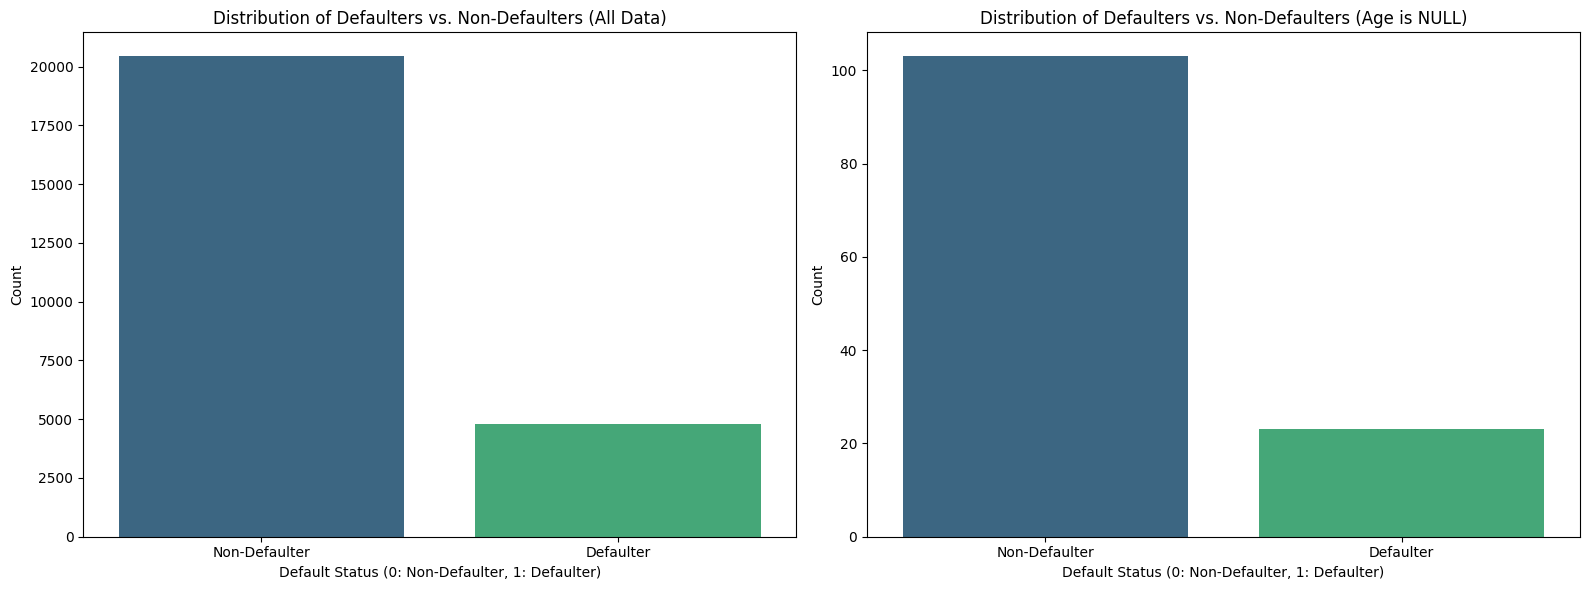

In [17]:
# Plot defaulter vs non defaulter side by side
plt.figure(figsize=(16, 6)) # Increase figure size to accommodate two plots

# Subplot 1: All data
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.countplot(x='next_month_default', data=df, palette='viridis')
plt.title('Distribution of Defaulters vs. Non-Defaulters (All Data)') # Added "All Data" for clarity
plt.xlabel('Default Status (0: Non-Defaulter, 1: Defaulter)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Non-Defaulter', 'Defaulter']) # Ensure correct labels on x-axis

# Subplot 2: Data where age is NULL
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.countplot(x='next_month_default', data=df[df['age'].isnull()], palette='viridis')
plt.title('Distribution of Defaulters vs. Non-Defaulters (Age is NULL)')
plt.xlabel('Default Status (0: Non-Defaulter, 1: Defaulter)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Non-Defaulter', 'Defaulter']) # Ensure correct labels on x-axis

plt.tight_layout() # Adjusts subplot parameters for a tight layout
plt.show()

In [18]:
# Calculate the ratio of defaulters to non-defaulters for all data
total_count = df.shape[0]
defaulter_count_all = df[df['next_month_default'] == 1].shape[0]
non_defaulter_count_all = total_count - defaulter_count_all

ratio_all = defaulter_count_all / non_defaulter_count_all

print(f"Ratio of Defaulters to Non-Defaulters (All Data): {ratio_all:.4f}")

# Calculate the ratio of defaulters to non-defaulters for data where age is NULL
df_age_null = df[df['age'].isnull()]
total_count_age_null = df_age_null.shape[0]
defaulter_count_age_null = df_age_null[df_age_null['next_month_default'] == 1].shape[0]
non_defaulter_count_age_null = total_count_age_null - defaulter_count_age_null

ratio_age_null = defaulter_count_age_null / non_defaulter_count_age_null

print(f"Ratio of Defaulters to Non-Defaulters (Age is NULL): {ratio_age_null:.4f}")


Ratio of Defaulters to Non-Defaulters (All Data): 0.2352
Ratio of Defaulters to Non-Defaulters (Age is NULL): 0.2233


The ratio of Defaulters to Non-Defaulters is almost same in both the cases. So we can drop them.

In [19]:
df.columns

Index(['Customer_ID', 'marriage', 'sex', 'education', 'LIMIT_BAL', 'age',
       'pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6', 'Bill_amt1',
       'Bill_amt2', 'Bill_amt3', 'Bill_amt4', 'Bill_amt5', 'Bill_amt6',
       'pay_amt1', 'pay_amt2', 'pay_amt3', 'pay_amt4', 'pay_amt5', 'pay_amt6',
       'AVG_Bill_amt', 'PAY_TO_BILL_ratio', 'next_month_default'],
      dtype='object')

In [20]:
ca=['sex', 'education', 'marriage', 'pay_0', 'pay_2',
       'pay_3', 'pay_4', 'pay_5', 'pay_6']
for i in ca:
    print (i,df[i].unique())

sex [0 1]
education [2 1 3 4 5 6 0]
marriage [2 1 3 0]
pay_0 [ 2  0 -2 -1  1  8  4  3  5  6  7]
pay_2 [ 2  0 -2 -1  7  4  3  1  5  6  8]
pay_3 [ 2 -2  0 -1  6  3  4  1  7  5  8]
pay_4 [ 0 -2 -1  2  5  3  4  7  6  1]
pay_5 [ 0 -1 -2  2  4  3  6  7  5]
pay_6 [ 0 -2 -1  2  3  4  5  7  6  8]


EDUCATION: (1=graduate school, 2=university, 3=high school, 4=others, 5=unknown, 6=unknown)
category 4,5,6 and 0 can Group into class 4

Marital status: (1=married, 2=single, 3=others)
We'll group categories 1 into category 3

We'll drop the 'Customer_ID' column as it is not useful.

In [6]:
def clean_and_transform(df):

    # Drop rows with missing 'age'
    df = df.dropna(subset=['age'])

    # Drop the 'Customer_ID' column
    if "Customer_ID" in df.columns:
        df.drop(["Customer_ID"], axis=1, inplace=True)

    # Replace values in 'education' column
    df['education'].replace({0:4, 5:4, 6:4}, inplace=True)

    # Replace values in 'marriage' column
    df['marriage'].replace({0:3}, inplace=True)

    return df

In [25]:
df=clean_and_transform(df)

In [26]:
df.head()

,marriage,sex,education,LIMIT_BAL,age,pay_0,pay_2,pay_3,pay_4,pay_5,pay_6,Bill_amt1,Bill_amt2,Bill_amt3,Bill_amt4,Bill_amt5,Bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,AVG_Bill_amt,PAY_TO_BILL_ratio,next_month_default
0,2,0,2,60000,25.0,2,2,2,0,0,0,60323.86,60728.22,56472.74,28602.01,22191.53,20750.63,2000.21,0.00,1134.85,1821.78,1500.03,1500.24,41511.50,0.03,0
1,2,1,1,290000,24.0,0,0,-2,-2,-1,0,11157.67,0.00,0.88,0.65,2700.96,1350.30,0.00,0.17,0.00,2700.10,0.00,1349.72,2534.50,0.27,0
2,1,0,2,180000,63.0,0,0,0,0,0,0,47930.96,48921.91,50034.26,50748.90,51902.56,52991.51,2086.94,2199.99,1845.66,2000.35,1923.00,1999.78,50422.00,0.04,0
3,1,1,2,210000,43.0,0,0,0,0,0,0,91152.44,92916.01,90652.30,85295.56,80416.75,76945.47,3348.07,3380.91,3400.45,2683.97,2744.00,2892.10,86229.50,0.04,0
4,2,0,1,280000,32.0,-2,-2,-2,-2,-2,-2,19666.40,999.04,3186.48,44932.48,2099.77,1.35,999.78,3186.27,45027.78,2100.09,0.01,0.27,11814.33,0.72,0


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25121 entries, 0 to 25246
Data columns (total 26 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   marriage            25121 non-null  int64  
 1   sex                 25121 non-null  int64  
 2   education           25121 non-null  int64  
 3   LIMIT_BAL           25121 non-null  int64  
 4   age                 25121 non-null  float64
 5   pay_0               25121 non-null  int64  
 6   pay_2               25121 non-null  int64  
 7   pay_3               25121 non-null  int64  
 8   pay_4               25121 non-null  int64  
 9   pay_5               25121 non-null  int64  
 10  pay_6               25121 non-null  int64  
 11  Bill_amt1           25121 non-null  float64
 12  Bill_amt2           25121 non-null  float64
 13  Bill_amt3           25121 non-null  float64
 14  Bill_amt4           25121 non-null  float64
 15  Bill_amt5           25121 non-null  float64
 16  Bill_amt6

In [36]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
marriage,25121.0,1.558099,0.521873,1.00,1.00,2.00,2.00,3.00
sex,25121.0,0.604713,0.488922,0.00,0.00,1.00,1.00,1.00
education,25121.0,1.840771,0.749179,1.00,1.00,2.00,2.00,4.00
LIMIT_BAL,25121.0,168358.823295,129866.750911,10000.00,50000.00,140000.00,240000.00,1000000.00
age,25121.0,35.438199,9.174998,21.00,28.00,34.00,41.00,79.00
pay_0,25121.0,-0.043111,1.099224,-2.00,-1.00,0.00,0.00,8.00
pay_2,25121.0,-0.159747,1.174062,-2.00,-1.00,0.00,0.00,8.00
pay_3,25121.0,-0.190558,1.172957,-2.00,-1.00,0.00,0.00,8.00
pay_4,25121.0,-0.240994,1.147502,-2.00,-1.00,0.00,0.00,7.00
pay_5,25121.0,-0.282393,1.114730,-2.00,-1.00,0.00,0.00,7.00


Now, Total 25121 clients is the dataset with no NULL values.

The average amount of credit card is \$168358. Minimal amount a credit card can receive is \$10000 while max value is \$1M.

In average, the client who owns a credit card is 35.43 year old in our sample, the yougest age one can get a credit card is 21 while the most senior age is 79.

19.04% of credit card contracts that will default next month.

# 2) Data Visualization

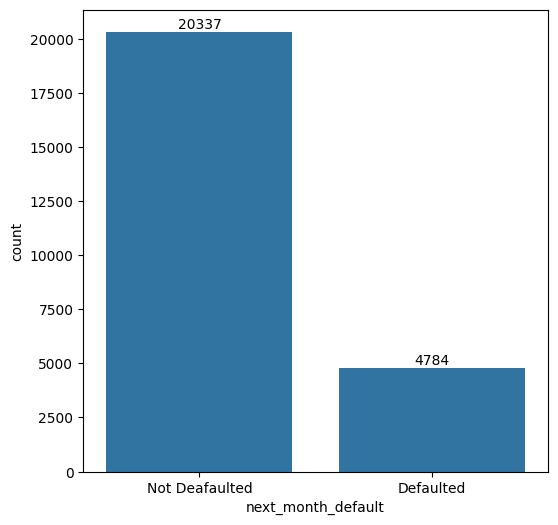

In [28]:
plt.figure(figsize=(6,6))
ax=sns.countplot(x= df['next_month_default'])
for label in ax.containers:
    ax.bar_label(label)
plt.xticks([0,1], labels=["Not Deafaulted", "Defaulted"])
plt.show()

The data is quite imbalance which about 19% of clients will default next month.

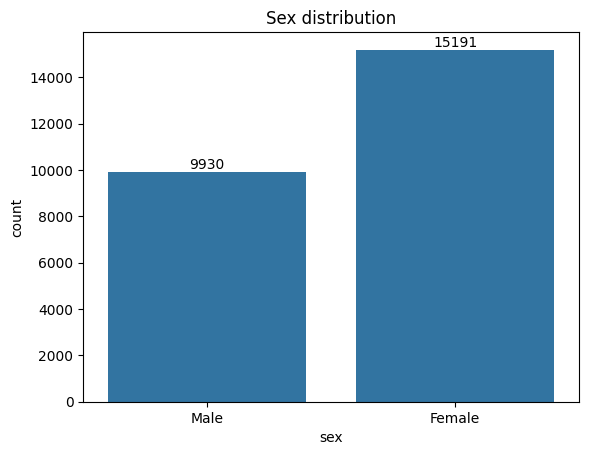

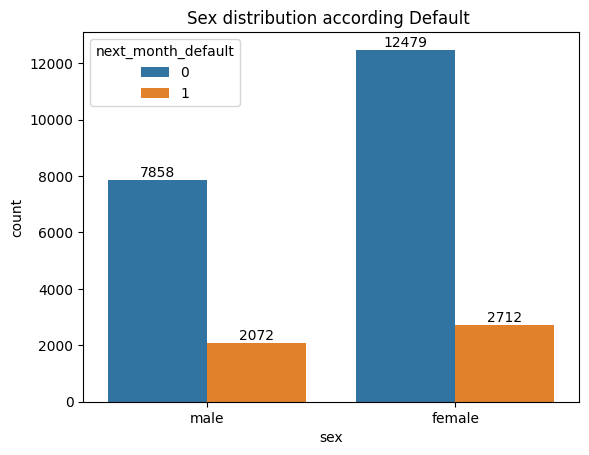

In [29]:
ax=sns.countplot(x= df['sex'])
for label in ax.containers:
    ax.bar_label(label)
plt.xticks([0,1], labels=["Male", "Female"])
plt.title("Sex distribution")
plt.show()

ax=sns.countplot(data=df, x="sex", hue="next_month_default")
for label in ax.containers:
    ax.bar_label(label)
plt.xticks([0,1], labels=["male", "female"])
plt.title("Sex distribution according Default ")
plt.show()

More Female clients own credit card than Male client.
21% of male clients fraud credit card while the ratio for female is around 18%.

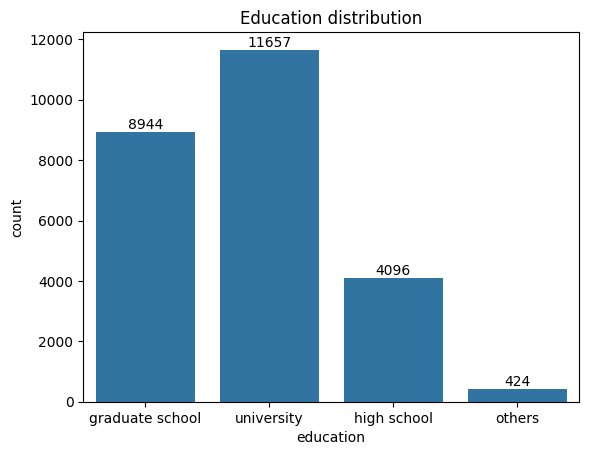

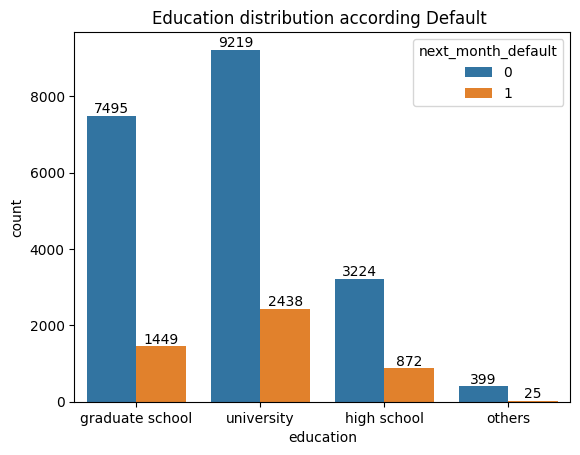

In [30]:
ax=sns.countplot(x= df['education'])
for label in ax.containers:
    ax.bar_label(label)
plt.xticks([0,1,2,3], labels=["graduate school", "university",'high school','others'])
plt.title("Education distribution")
plt.show()

ax=sns.countplot(data=df, x="education", hue="next_month_default")
for label in ax.containers:
    ax.bar_label(label)
plt.xticks([0,1,2,3], labels=["graduate school", "university",'high school','others'])
plt.title("Education distribution according Default ")
plt.show()

University students are the group which highest number customers using credit cards (46%).

High school students are the group which has highest fraud cases(21%), followed by university student(20%).

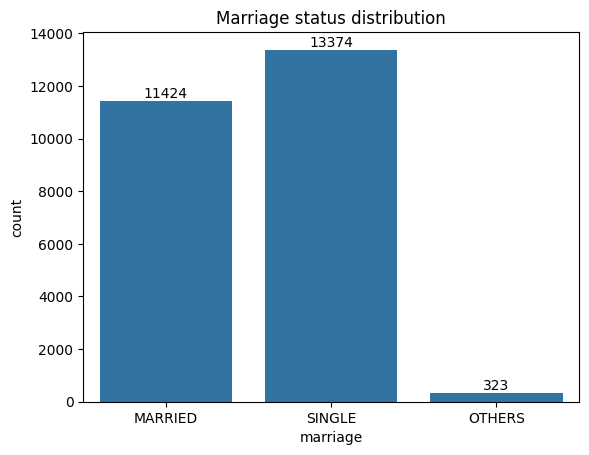

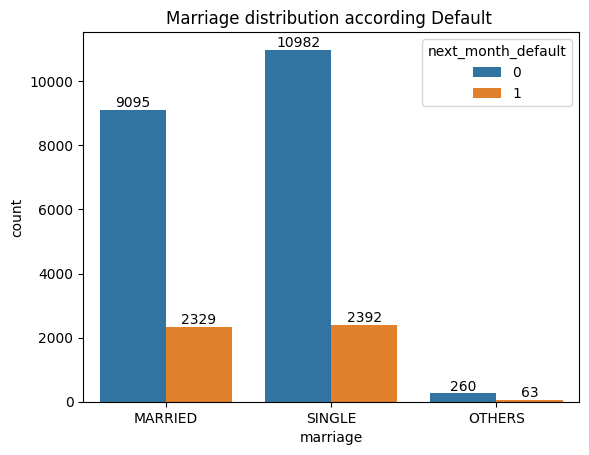

In [31]:
ax=sns.countplot(x= df['marriage'])
for label in ax.containers:
    ax.bar_label(label)
plt.xticks([0,1,2], labels=["MARRIED", "SINGLE",'OTHERS'])
plt.title("Marriage status distribution")
plt.show()

ax=sns.countplot(data=df, x="marriage", hue="next_month_default")
for label in ax.containers:
    ax.bar_label(label)
plt.xticks([0,1,2], labels=["MARRIED", "SINGLE",'OTHERS'])
plt.title("Marriage distribution according Default ")
plt.show()

Single is the group which highest number of customers using credit cards (53%).

Married people are the group which has highest fraud cases(20%). Others are not considered since they are very small in numbers.

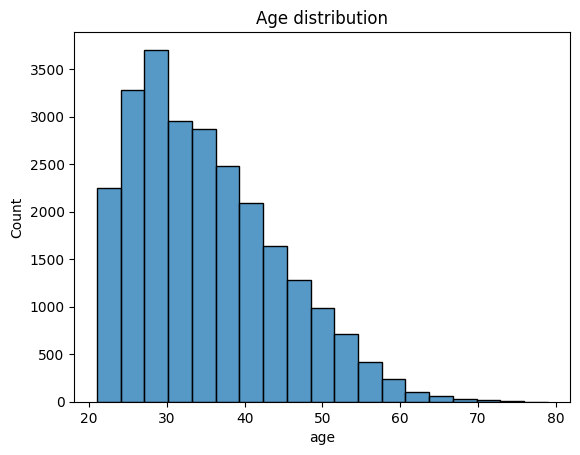

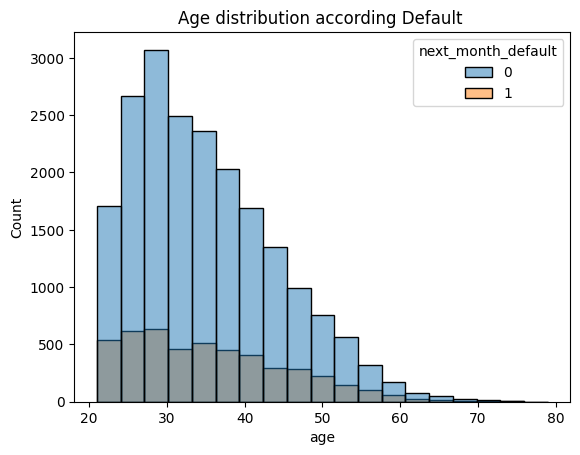

In [32]:
sns.histplot(data=df, x="age",binwidth=3)
plt.title("Age distribution")
plt.show()

sns.histplot(data=df, x="age", hue="next_month_default", binwidth=3)
plt.title("Age distribution according Default ")
plt.show()

Histogram is right-skewed meaning the older customers are less likely to use credit cards.

The main client is in their 30s.

Customers in their 30s are also the most prone to credit fraud.

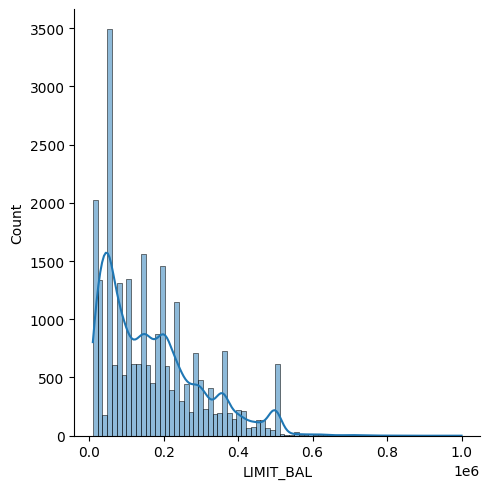

In [33]:
sns.displot(df.LIMIT_BAL, kde=True)

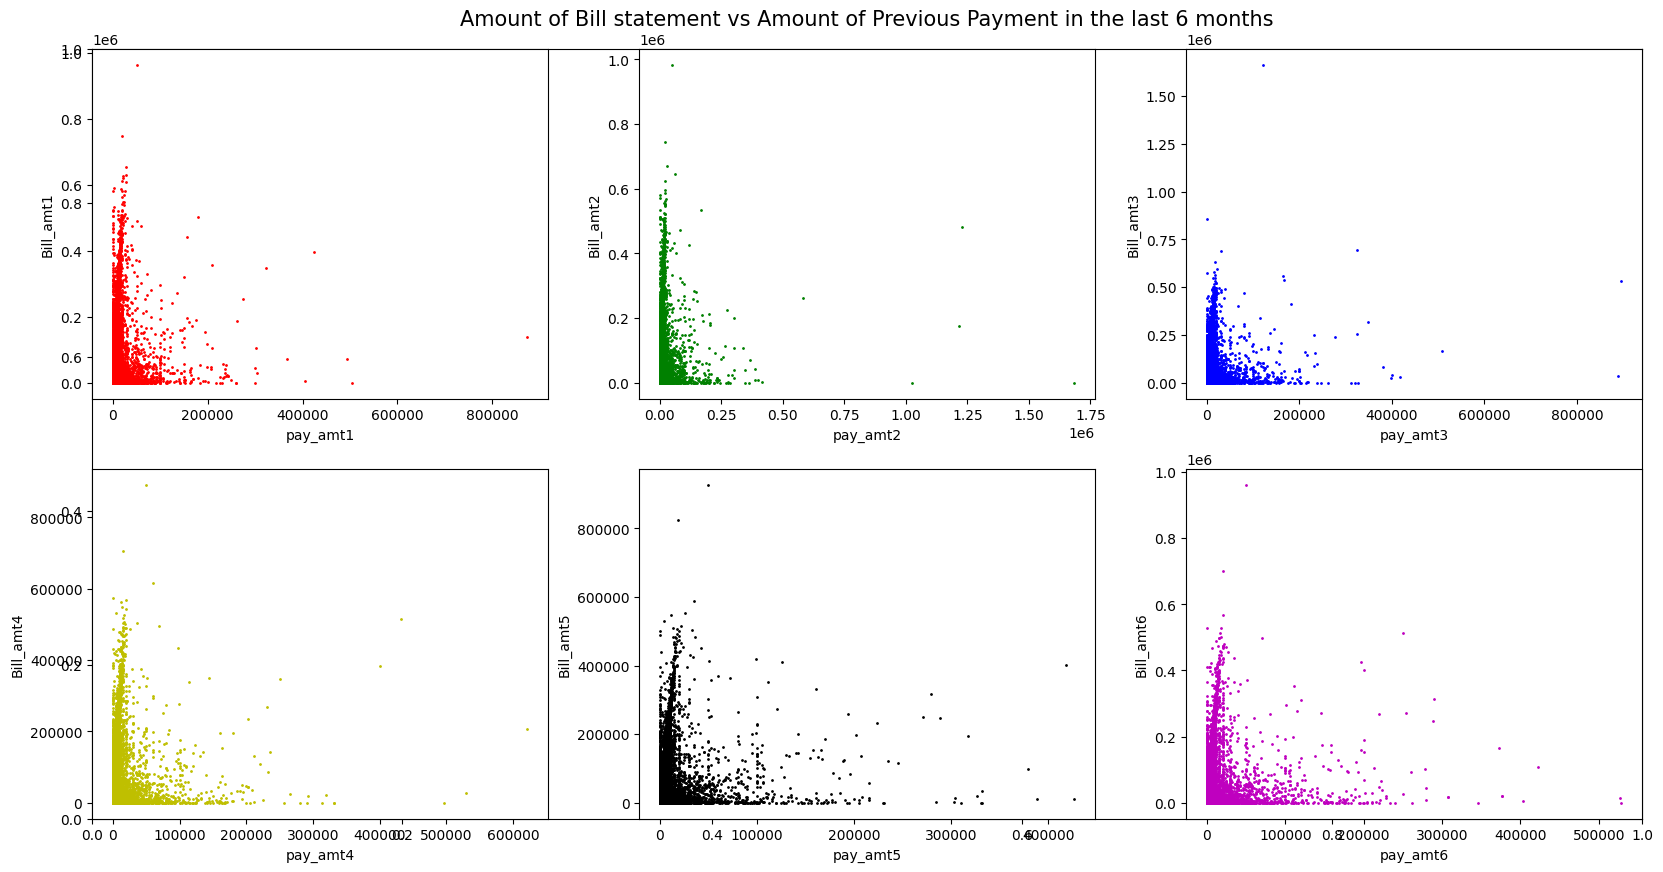

In [34]:
plt.subplots(figsize=(20,10))
plt.subplot(231)
plt.scatter(x=df.pay_amt1, y=df.Bill_amt1, c='r', s=1)
plt.xlabel('pay_amt1')
plt.ylabel('Bill_amt1')

plt.subplot(232)
plt.scatter(x=df.pay_amt2, y=df.Bill_amt2, c='g', s=1)
plt.xlabel('pay_amt2')
plt.ylabel('Bill_amt2')
plt.title('Amount of Bill statement vs Amount of Previous Payment in the last 6 months', fontsize=15)

plt.subplot(233)
plt.scatter(x=df.pay_amt3, y=df.Bill_amt3, c='b', s=1)
plt.xlabel('pay_amt3')
plt.ylabel('Bill_amt3')

plt.subplot(234)
plt.scatter(x=df.pay_amt4, y=df.Bill_amt4, c='y', s=1)
plt.xlabel('pay_amt4')
plt.ylabel('Bill_amt4')

plt.subplot(235)
plt.scatter(x=df.pay_amt5, y=df.Bill_amt5, c='black', s=1)
plt.xlabel('pay_amt5')
plt.ylabel('Bill_amt5')

plt.subplot(236)
plt.scatter(x=df.pay_amt6, y=df.Bill_amt6, c='m', s=1)
plt.xlabel('pay_amt6')
plt.ylabel('Bill_amt6')


plt.show()

<Axes: >

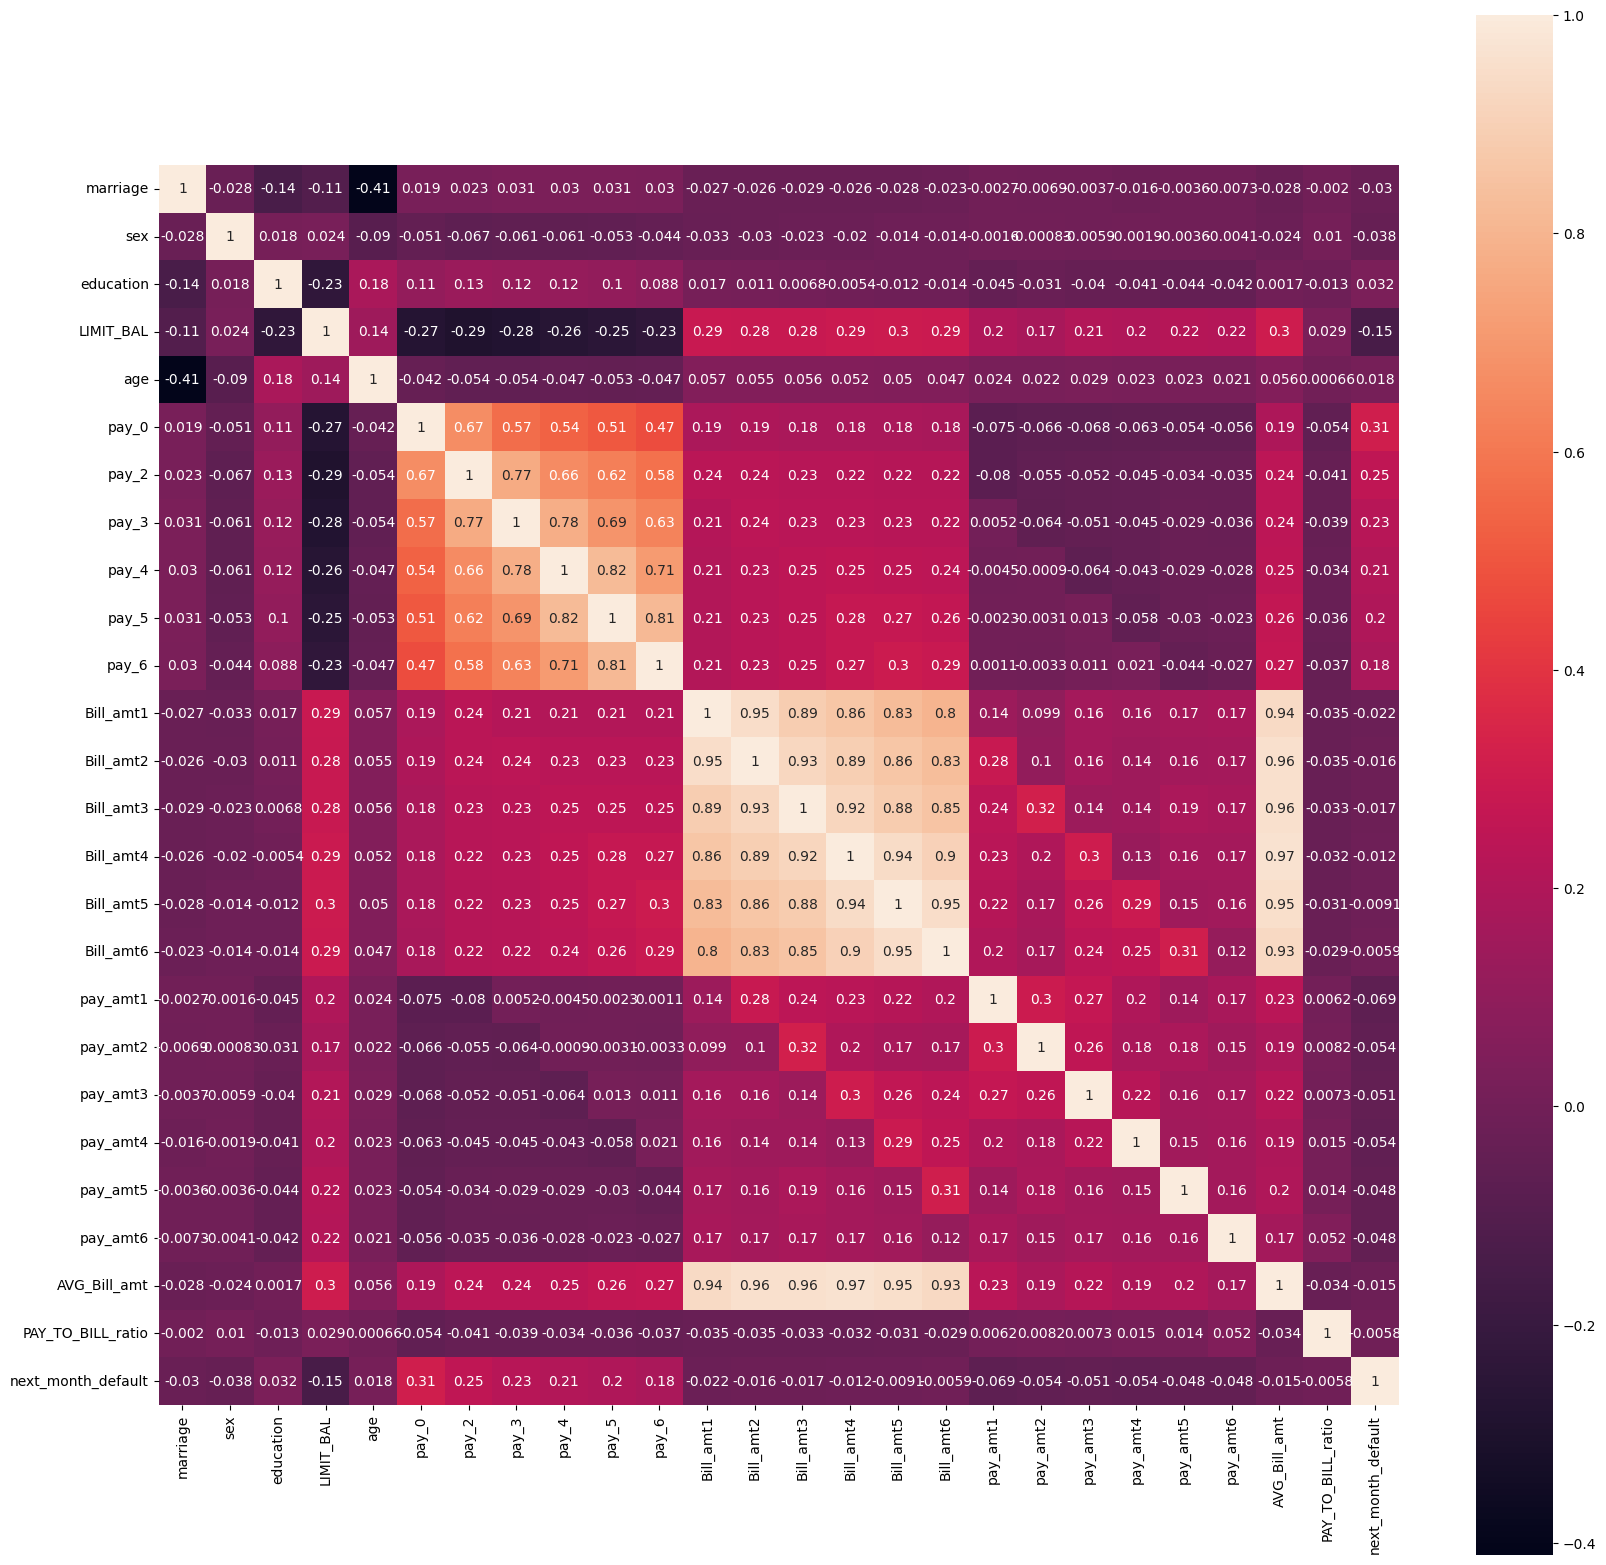

In [35]:
plt.figure(figsize = (20,20))
sns.heatmap(df.corr(),annot = True,square = True)

Correlation is high among PAY_0,2,3,4,5,6 and BILL_AMT1,2,3,4,5,6.

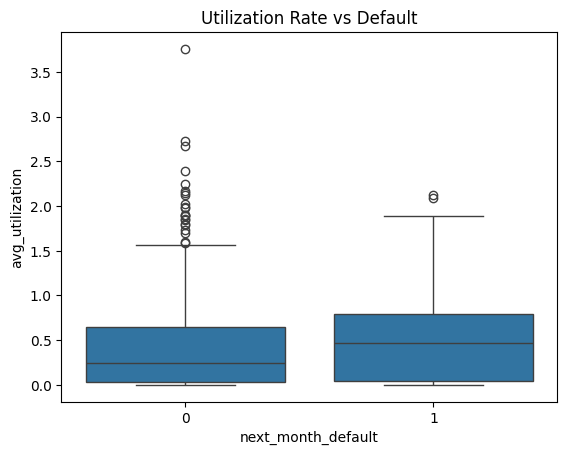

In [38]:
# --- Utilization Rate Features ---
for i in range(1, 7):
    df[f'utilization_{i}'] = df[f'Bill_amt{i}'] / df['LIMIT_BAL']

df['avg_utilization'] = df[[f'utilization_{i}' for i in range(1, 7)]].mean(axis=1)

sns.boxplot(x='next_month_default', y='avg_utilization', data=df)
plt.title('Utilization Rate vs Default')
plt.show()


Median utilization rate for non-defaulters (0) is around **0.2**, while for defaulters (1) it rises to approximately **0.5**.

Some non-defaulters have utilization rates >3.5, showing extreme credit usage.

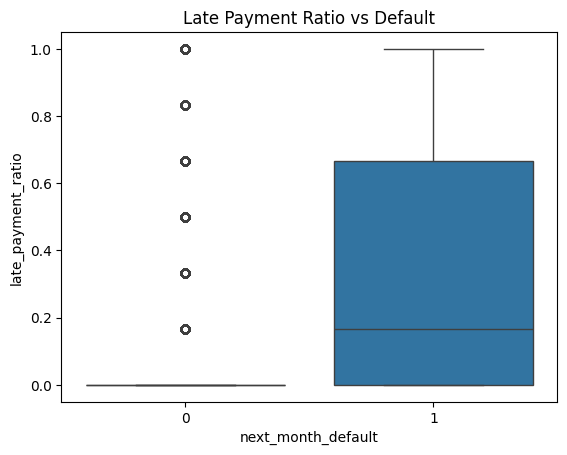

In [72]:
# --- Late Payment Ratio ---
pay_features = ['pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6']

df['late_payments_count'] = (df[pay_features] > 0).sum(axis=1)
df['late_payment_ratio'] = df['late_payments_count'] / len(pay_features)

sns.boxplot(x='next_month_default', y='late_payment_ratio', data=df)
plt.title('Late Payment Ratio vs Default')
plt.show()

Median late payment ratio for non-defaulters is **0.0**, while defaulters have a median of around **0.17**.

Defaulters frequently have late payment ratios between **0.5 to 1.0**, indicating habitual late payment behavior.

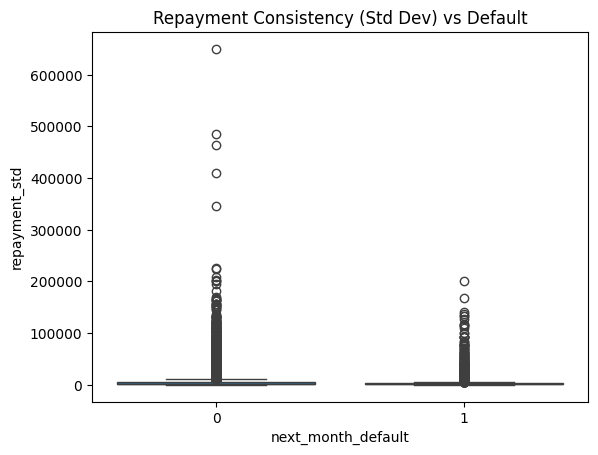

In [45]:
# --- Repayment Consistency ---
pay_amt_features = [f'pay_amt{i}' for i in range(1, 7)]
df['repayment_std'] = df[pay_amt_features].std(axis=1)

sns.boxplot(x='next_month_default', y='repayment_std', data=df)
plt.title('Repayment Consistency (Std Dev) vs Default')
plt.show()

Median repayment standard deviation for both groups is **near 0**, indicating most customers repay consistently.

Some repayment std devs reach **600,000+** among non-defaulters, likely driven by very large repayment amounts.


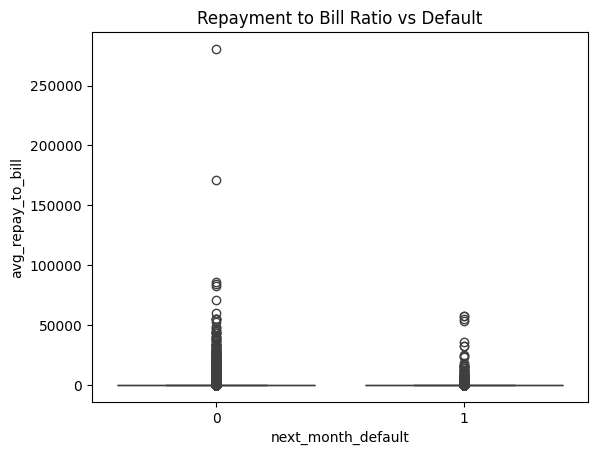

In [46]:
# --- Repayment to Bill Ratio (Per Month Aggregates) ---
for i in range(1, 7):
    df[f'repay_to_bill_{i}'] = df[f'pay_amt{i}'] / (df[f'Bill_amt{i}'] + 1)  # Avoid div by zero

df['avg_repay_to_bill'] = df[[f'repay_to_bill_{i}' for i in range(1, 7)]].mean(axis=1)

sns.boxplot(x='next_month_default', y='avg_repay_to_bill', data=df)
plt.title('Repayment to Bill Ratio vs Default')
plt.show()

Median repayment-to-bill ratio is **close to 0** for both groups, with some extreme outliers exceeding **250,000** for non-defaulters.


next_month_default    1.000000
late_payment_ratio    0.390284
avg_utilization       0.111457
avg_repay_to_bill    -0.021557
repayment_std        -0.067345
Name: next_month_default, dtype: float64


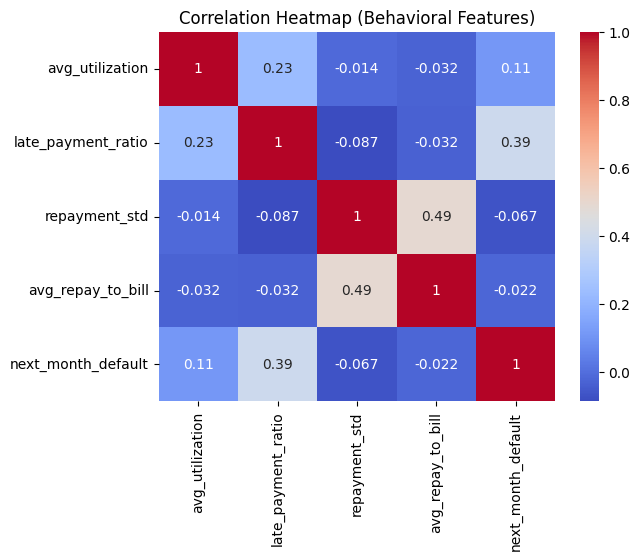

In [47]:
# --- Correlation with Target ---
behavioral_cols = ['avg_utilization', 'late_payment_ratio', 'repayment_std', 'avg_repay_to_bill']
corrs = df[behavioral_cols + ['next_month_default']].corr()['next_month_default'].sort_values(ascending=False)
print(corrs)

sns.heatmap(df[behavioral_cols + ['next_month_default']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap (Behavioral Features)')
plt.show()

Among behavioral features, **late_payment_ratio (0.39)** is the **strongest predictor** of default risk.

# Feature Engineering

Now, we'll try different feature and consider only those which are significantly meaningful.

In [11]:
pay_cols = ['pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6']
bill_cols = ['Bill_amt1', 'Bill_amt2', 'Bill_amt3', 'Bill_amt4', 'Bill_amt5', 'Bill_amt6']
pay_amt_cols = ['pay_amt1', 'pay_amt2', 'pay_amt3', 'pay_amt4', 'pay_amt5', 'pay_amt6']

Now, we'll choose our final features to incorporate in the model for best results.

In [12]:
def feature_engineering_final(df):

  df['Credit_Utilization_Ratio_avg'] = (df[bill_cols].sum(axis=1) / len(bill_cols)) / df['LIMIT_BAL']

  df['Delinquency_Streak'] = df[pay_cols].apply(
        lambda row: np.max(np.split(row.values >= 1, np.where(~(row.values >= 1))[0])[0].sum() if np.any(row.values >= 1) else 0, axis=0),
        axis=1)

  df['Num_Delayed_Payments'] = (df[pay_cols] > 0).sum(axis=1)

  df['Recent_Overdue_Count'] = (df[['pay_0', 'pay_2', 'pay_3']] > 0).sum(axis=1)

  df['Max_Delay_Months'] = df[pay_cols].max(axis=1)

  df['MaxDelay_to_Limit_ratio'] = df['Max_Delay_Months'] / df['LIMIT_BAL']

  df['Payment_Volatility'] = df[pay_cols].std(axis=1).fillna(0)

  total_bill_sum = df[bill_cols].sum(axis=1)
  total_payment_sum = df[pay_cols].sum(axis=1)
  df['Total_Payment_to_Total_Bill'] = np.where(total_bill_sum != 0, total_payment_sum / total_bill_sum, 0)

  df['Utilization_Payment_Interaction'] = df['Credit_Utilization_Ratio_avg'] * df['Total_Payment_to_Total_Bill']

  return df

In [85]:
df1=pd.read_csv('train_dataset_final1.csv')

In [86]:
df1=clean_and_transform(df1)

In [87]:
df1=feature_engineering_final(df1)

<Axes: >

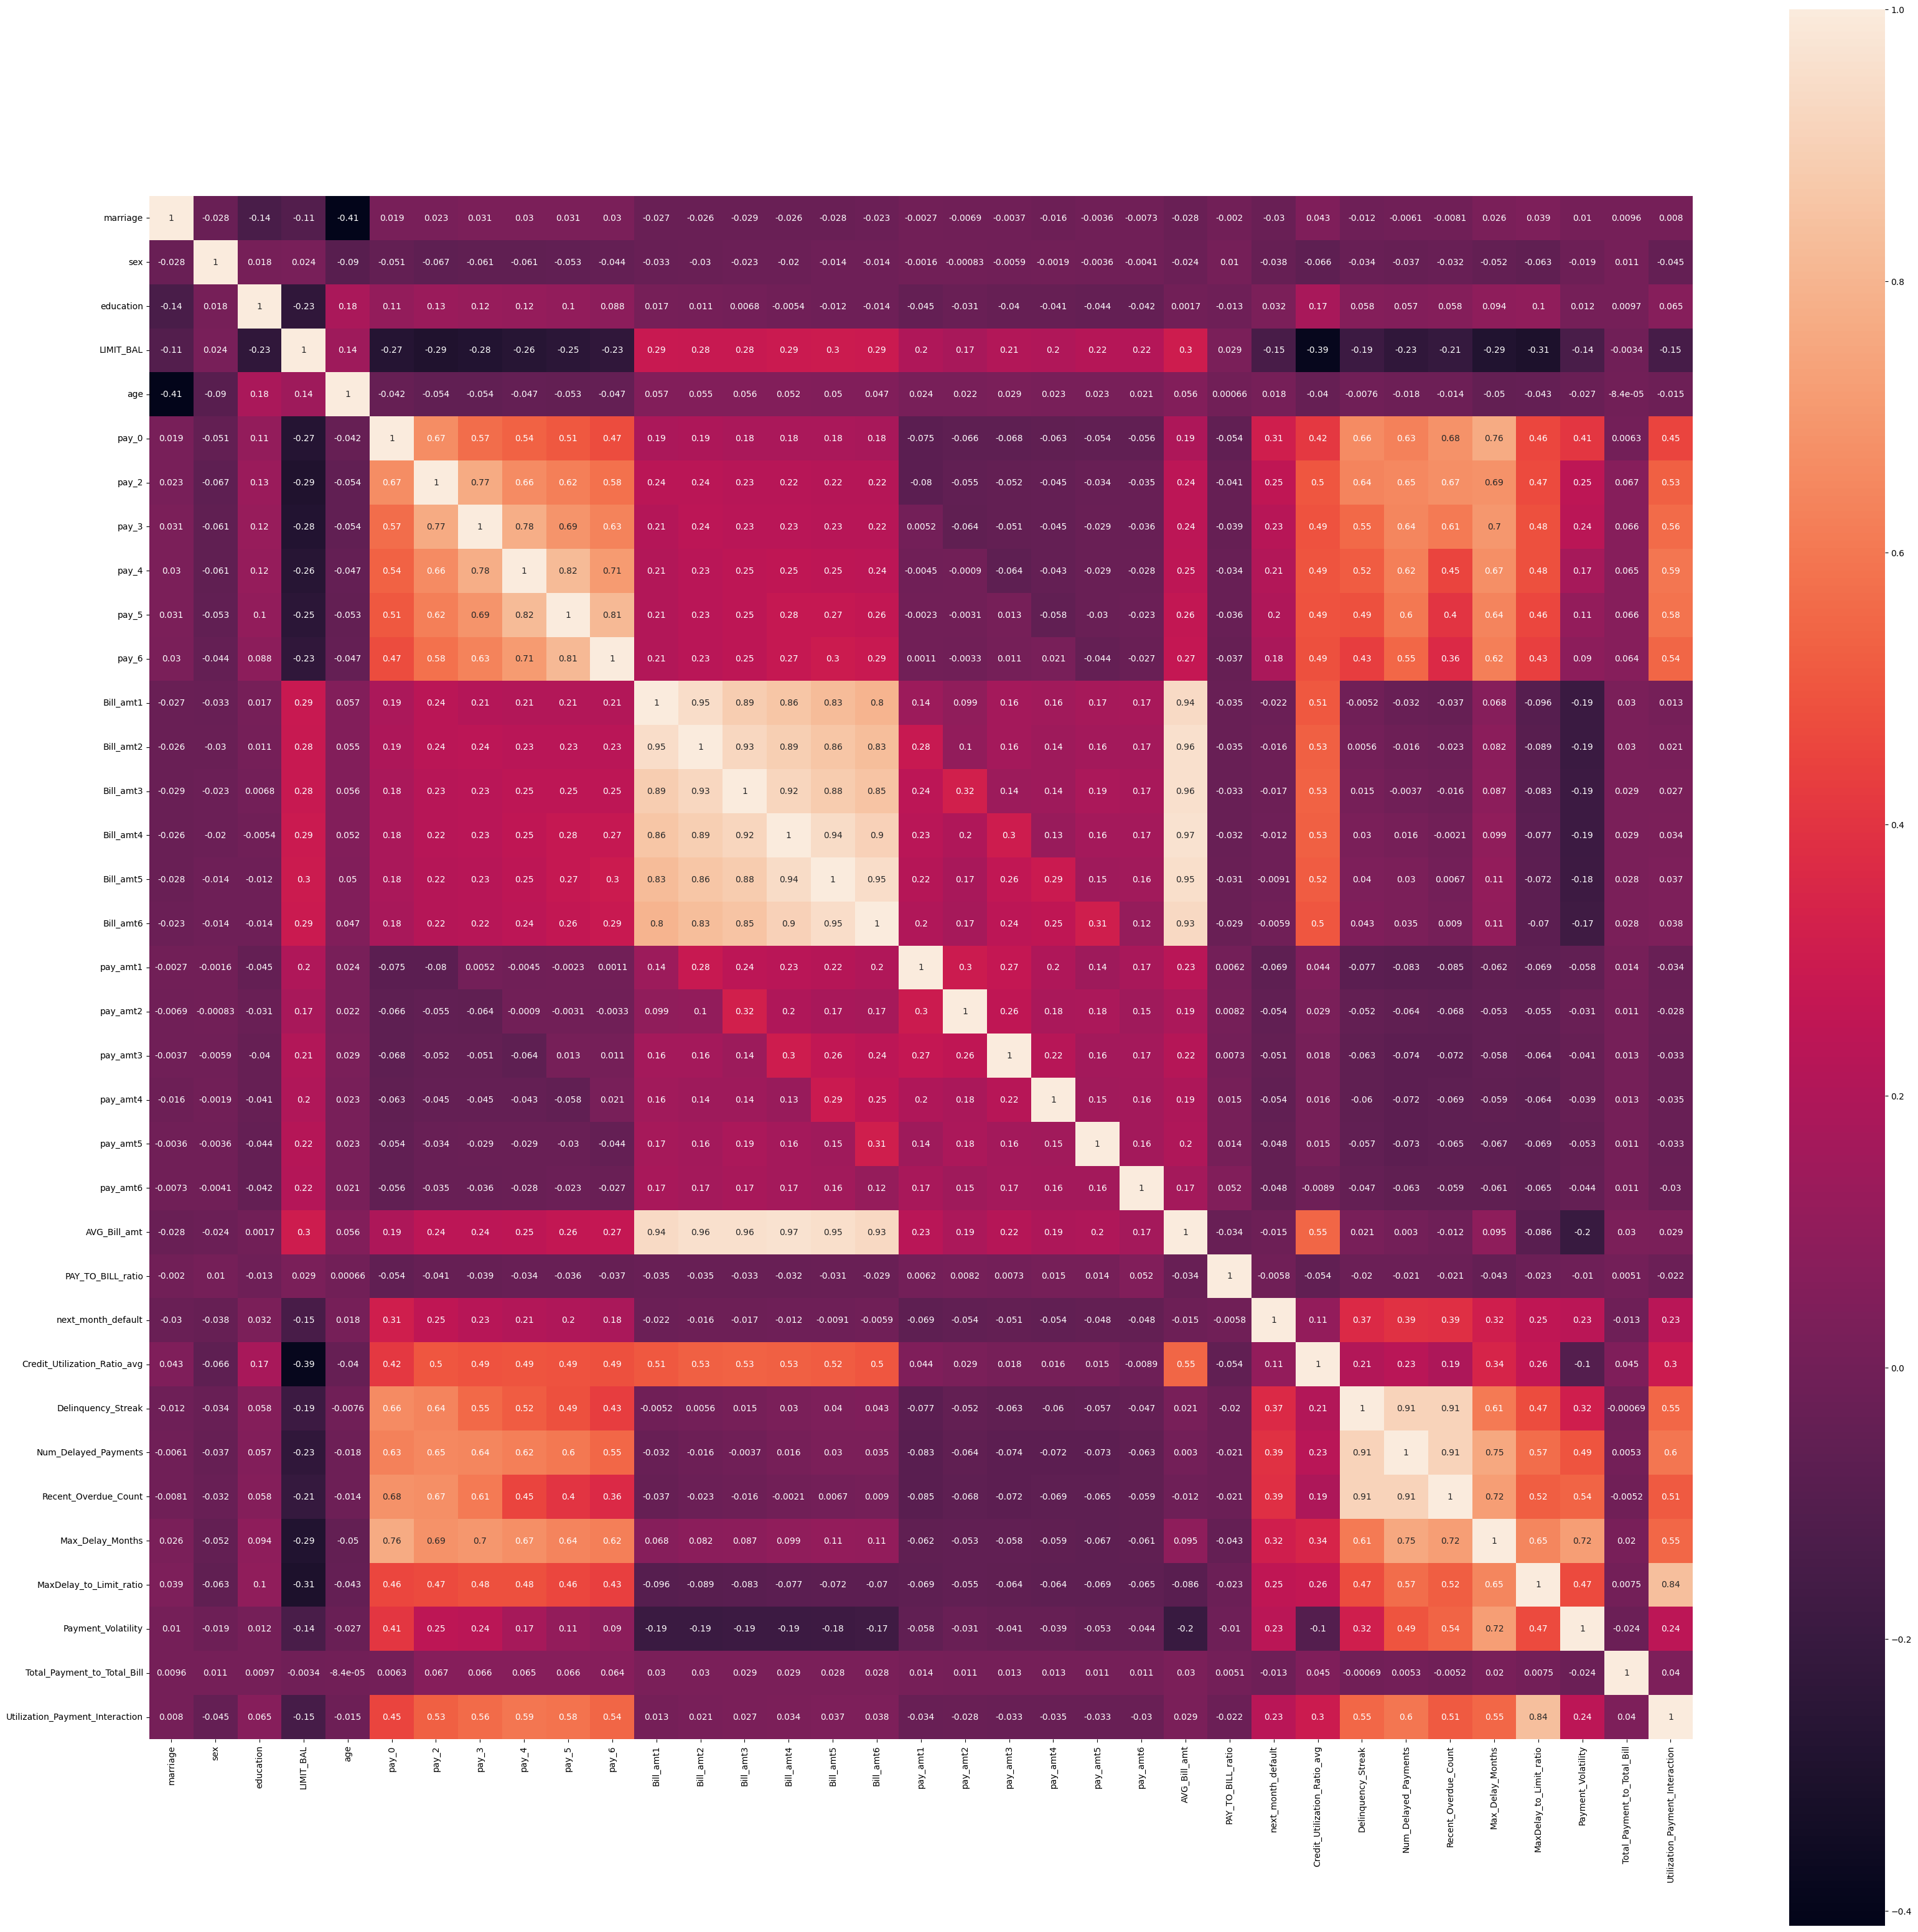

In [88]:
plt.figure(figsize = (40,40))
sns.heatmap(df1.corr(),annot = True,square = True)

In [90]:
df1.corr()['next_month_default'].sort_values(ascending=False)


,next_month_default
next_month_default,1.000000
Num_Delayed_Payments,0.390284
Recent_Overdue_Count,0.386970
Delinquency_Streak,0.365815
Max_Delay_Months,0.316310
pay_0,0.313244
MaxDelay_to_Limit_ratio,0.252793
pay_2,0.252776
Payment_Volatility,0.234730
Utilization_Payment_Interaction,0.228383
